In [1]:
import pandas as pd
import numpy as np

In [2]:
class Option:
    def __init__(self, strike: float, premium: float, expiry: str):
        self.strike = strike
        self.premium = premium
        self.expiry = expiry
        self.spot_price = None

    def insert_spot(self, spot_price: float):
        self.spot_price = spot_price
    
    def short_call(self):
        # Payoff for short call: premium received - intrinsic value of the option
        intrinsic_value = np.maximum(0, self.spot_price - self.strike)
        return self.premium - intrinsic_value
    
    def long_call(self):
        # Payoff for long call: intrinsic value - premium paid
        intrinsic_value = np.maximum(0, self.spot_price - self.strike)
        return intrinsic_value - self.premium
    
    def short_put(self):
        # Payoff for short put: premium received - intrinsic value of the option
        intrinsic_value = np.maximum(0, self.strike - self.spot_price)
        return self.premium - intrinsic_value
    
    def long_put(self):
        # Payoff for long put: intrinsic value - premium paid
        intrinsic_value = np.maximum(0, self.strike - self.spot_price)
        return intrinsic_value - self.premium


class IronCondor:
    def __init__(self, direction: str, strikes: dict, premiums: dict, expiry: str):
        """
        Initialize the Iron Condor strategy with strikes and premiums for the options.
        
        direction: long, (short) Iron Condor
        1. Short (Long) 1 OTM Put (strike 1)
        2. Long (Short) 1 close to ATM Put (strike 2)
        3. Long (Short) 1 close to ATM Call (strike 3)
        4. Short (Long) 1 OTM Call (strike 4)        

        strikes: a dictionary of strikes for the 4 options (strike1 to strike4)
        premiums: a dictionary of premiums for the 4 options (premium1 to premium4)
        expiry: expiration date of the options
        """
        self.strikes = strikes
        self.premiums = premiums
        self.direction = direction
        self.expiry = expiry
        self.short_put_option = Option(strikes['strike1'], premiums['premium1'], expiry)
        self.long_put_option = Option(strikes['strike2'], premiums['premium2'], expiry)
        self.long_call_option = Option(strikes['strike3'], premiums['premium3'], expiry)
        self.short_call_option = Option(strikes['strike4'], premiums['premium4'], expiry)

    def initial_cashflow(self):
        """
        Calculate the initial cashflow of the Iron Condor strategy.
        """
        if self.direction == "long":
            initial_cashflow = self.premiums['premium1'] - self.premiums['premium2'] - self.premiums['premium3'] + self.premiums['premium4']
        elif self.direction == "short":
            initial_cashflow = -self.premiums['premium1'] + self.premiums['premium2'] + self.premiums['premium3'] - self.premiums['premium4']
        
        return initial_cashflow

    def insert_spot(self, spot_price: float):
        """
        Insert the current spot price for all the options in the Iron Condor strategy.
        """
        self.short_put_option.insert_spot(spot_price)
        self.long_put_option.insert_spot(spot_price)
        self.long_call_option.insert_spot(spot_price)
        self.short_call_option.insert_spot(spot_price)
    
    def payoff(self):
        """
        Calculate the total payoff (profit or loss) of the Iron Condor strategy.
        
        direction: 'long' for long Iron Condor, 'short' for short Iron Condor
        """
        if self.direction == "long":
            short_put = self.short_put_option.short_put()
            long_put = self.long_put_option.long_put()
            long_call = self.long_call_option.long_call()
            short_call = self.short_call_option.short_call()
            total_payoff = short_put + long_put + long_call + short_call
        elif self.direction == "short":
            long_put = -self.long_put_option.long_put()
            short_put = -self.short_put_option.short_put()
            short_call = -self.short_call_option.short_call()
            long_call = -self.long_call_option.long_call()
            total_payoff = long_put + short_put + short_call + long_call
        
        return total_payoff.iloc[0] if isinstance(total_payoff, pd.Series) else total_payoff
    
    def target_profit(self):
        """
        Calculate the target profit for the Iron Condor strategy.
        """
        if self.direction == "long":
            self.long_call_option = Option(self.strikes['strike3'], self.premiums['premium3'], self.expiry)
            self.short_call_option = Option(self.strikes['strike4'], self.premiums['premium4'], self.expiry)
            self.long_call_option.insert_spot(self.strikes["strike4"] + 5)
            self.short_call_option.insert_spot(self.strikes["strike4"] + 5)
            target_profit = self.premiums["premium1"] - self.premiums["premium2"] + self.long_call_option.long_call() + self.short_call_option.short_call()
        elif self.direction == "short":
            target_profit = self.initial_cashflow()
        
        return target_profit

class OptionsBacktester:
    def __init__(self,
                 signal_df: pd.DataFrame,
                 spot_price_df: pd.DataFrame,
                 options_df: pd.DataFrame,
                 upper_threshold: float,
                 lower_threshold: float,
                 option_type: str,
                 dynamic_option_strategy: bool = False,
                 dynamic_strike: bool = False,):
        self.signal_df = signal_df
        self.signal_df.columns = ["signal"]
        self.spot_price_df = spot_price_df
        self.options_df = options_df
        self.upper_threshold = upper_threshold
        self.lower_threshold = lower_threshold
        self.option_type = option_type
        self.dynamic_option_strategy = dynamic_option_strategy
        self.dynamic_strike = dynamic_strike

        self.comb_df = pd.concat([self.signal_df, self.spot_price_df.shift(), self.options_df.shift()], axis=1)
        self.comb_df["action"] = np.where(self.comb_df["signal"] > self.upper_threshold, 1, np.where(self.comb_df["signal"] < self.lower_threshold, -1, 0))

    def long_short_vol_df(self):
        self.trading_df = {}
        for index, row in self.comb_df.iterrows():
            if row["action"] != 0:
                self.trading_df[index] = self.comb_df.loc[index]

In [3]:
strikes = {
    'strike1': 95,
    'strike2': 100,
    'strike3': 105,
    'strike4': 110 
}

premiums = {
    'premium1': 0.7,
    'premium2': 2.1,
    'premium3': 2.35,
    'premium4': 0.95 
}

# strikes = {
#     "strike1": 400,
#     "strike2": 450,
#     "strike3": 550,
#     "strike4": 600
# }

# premiums = {
#     "premium1": 0.72,
#     "premium2": 6.15,
#     "premium3": 7.89,
#     "premium4": 1.94
# }

expiry = "2024-12-31"

ironcondor = IronCondor(direction="short", strikes=strikes, premiums=premiums, expiry=expiry)
print(ironcondor.initial_cashflow())
ironcondor.insert_spot(100)
print(ironcondor.payoff())
print(ironcondor.target_profit())

2.8
2.8000000000000003
2.8


## Code to filter down the options data to only rows where strike matches spot

In [4]:
# upper_threshold = 1
# lower_threshold = -1

# aapl_vrp = pd.read_csv("data/AAPL_vrp_standardised.csv", parse_dates=True, index_col=0)

# aapl = pd.read_hdf("data/all_tickers_time_series.hf5", key="AAPL").drop_duplicates().set_index("date")

# aapl.index = pd.to_datetime(aapl.index)

# options_data = pd.read_hdf("data/all_options_data.h5", key="AAPL").set_index("date")
# options_data['exdate'] = pd.to_datetime(options_data['exdate'])
# options_data.index = pd.to_datetime(options_data.index)


# # options_data_filtered = pd.DataFrame()
# options_data['price'] = aapl["prc"]
# options_data["strike_price"] = options_data["strike_price"] / 1000
# # for date in options_data.index.unique():
# #     if options_data.loc[date]["exdate"].nunique() > 1:
# #         options_data_filtered = pd.concat([options_data_filtered, options_data.loc[date].query("exdate == exdate.min()")], axis=0)


# options_data_filtered = options_data.groupby("date").apply(lambda x: x.query("exdate == exdate.min()")).reset_index(level=0, drop=True)

# # options_data_filtered["strike_minus_price"] = np.abs(options_data_filtered["strike_price"] - options_data_filtered["price"])
# # new_df = options_data_filtered.groupby("date").apply(lambda x: x.query("strike_minus_price == strike_minus_price.min()")).reset_index(level=0, drop=True)
# # date_counts = new_df.index.value_counts()
# # def filter_max_open_interest(x):
# #     if len(x) >= 2:
# #         return x.query("open_interest == open_interest.max()")
# #     return x 

# # new_new_df = new_df.groupby(['date', 'cp_flag']).apply(filter_max_open_interest).reset_index(level=[0, 1], drop=True)

# # comb_df = pd.concat([new_new_df, aapl_vrp], axis=1) # the above block is only used if i want to filter the options data for strike close to spot
# comb_df = pd.concat([options_data_filtered, aapl_vrp], axis=1)
# comb_df = comb_df.dropna()
# comb_df["action"] = np.where(comb_df["vrp_standardised"] > upper_threshold, 1, np.where(comb_df["vrp_standardised"] < lower_threshold, -1, 0))

In [5]:
day_map = {0: "Monday", 1: "Tuesday", 2: "Wednesday", 3: "Thursday", 4: "Friday", 5: "Saturday", 6: "Sunday"}

xlu_options = pd.read_hdf("data/etf_options_data.hf5", key="XLU")
xlu_options = xlu_options.set_index("date")
xlu_options["strike_price"] = xlu_options["strike_price"] / 1000
xlu_filtered_options = xlu_options.groupby("date").apply(lambda x: x.query("exdate == exdate.max()")).reset_index(level=0, drop=True)
xlu_filtered_options["day"] = xlu_filtered_options.index.weekday.map(day_map)
xlu_filtered_options["ex_day"] = xlu_filtered_options["exdate"].dt.weekday.map(day_map)
xlu_filtered_options

,ticker,exdate,cp_flag,strike_price,best_bid,best_offer,open_interest,impl_volatility,delta,gamma,theta,vega,volume,day,ex_day
date,,,,,,,,,,,,,,,
2000-01-10,XLU,2000-01-22,C,31.0,0.0000,0.1250,0.0,0.423886,0.068868,0.062562,-4.271427,0.662345,0.0,Monday,Saturday
2000-01-10,XLU,2000-01-22,P,29.0,1.4375,1.6250,0.0,0.271660,-0.839551,0.179317,-4.941929,1.211415,0.0,Monday,Saturday
2000-01-10,XLU,2000-01-22,P,30.0,2.3750,2.6250,0.0,0.353248,-0.899561,0.099878,-4.593377,0.872273,0.0,Monday,Saturday
2000-01-10,XLU,2000-01-22,C,28.0,0.0625,0.1875,0.0,0.143454,0.283783,0.471890,-3.686701,1.692336,0.0,Monday,Saturday
2000-01-10,XLU,2000-01-22,C,27.0,0.5625,0.7500,0.0,0.140491,0.799844,0.397932,-2.952004,1.393989,0.0,Monday,Saturday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-08-31,XLU,2023-09-08,P,73.5,10.2000,10.5500,0.0,NaN,NaN,NaN,NaN,NaN,0.0,Thursday,Friday
2023-08-31,XLU,2023-09-08,P,90.0,26.7000,27.2000,0.0,NaN,NaN,NaN,NaN,NaN,0.0,Thursday,Friday
2023-08-31,XLU,2023-09-08,P,72.5,9.3000,9.5500,0.0,NaN,NaN,NaN,NaN,NaN,0.0,Thursday,Friday


## XLU

### Pulling data

In [6]:
xlu_pred = pd.read_csv("data/xlu_pred.csv", parse_dates=True, index_col=0).rename(columns={"0": "Rolling Pred"})
xlu_iv = pd.read_csv("data/XLU_IV.csv", parse_dates=True, index_col=0)
xlu_vrp = (xlu_iv["Average IV"] - xlu_pred["Rolling Pred"]).dropna()

<Axes: >

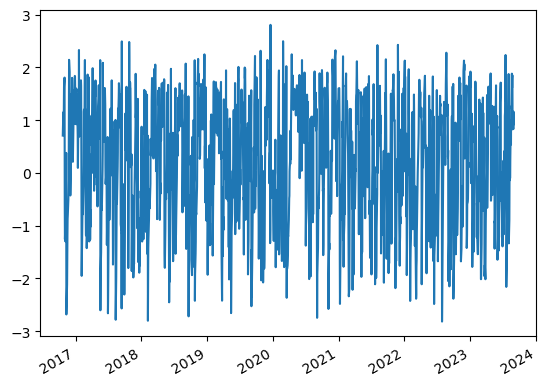

In [7]:
from data_wrangling import rolling_z_score
xlu_vrp_standardised = rolling_z_score(xlu_vrp, window=10)
xlu_vrp_standardised.plot()

### Merge VRP data with options data

In [8]:
upper_threshold = 1.75
lower_threshold = -1.75

xlu_filtered_options["vrp"] = xlu_vrp_standardised
xlu_time_series = pd.read_hdf("data/etf_series.hf5", key="XLU")
xlu_time_series["day"] = xlu_time_series.index.weekday
xlu_time_series["vrp"] = xlu_vrp_standardised
xlu_time_series["signal"] = np.where(xlu_time_series["vrp"] > upper_threshold, 1, np.where(xlu_time_series["vrp"] < lower_threshold, -1, 0))
xlu_time_series["action"] = np.where((xlu_time_series["signal"] == 1)  & (xlu_time_series.index.weekday != 4), 1, 
                                     np.where((xlu_time_series["signal"] == -1) & (xlu_time_series.index.weekday != 4), -1, 
                                              0))
xlu_time_series.dropna(inplace=True)
xlu_time_series

def ensure_weekly_action(df):
    last_action = 0
    last_week = -1

    for i in range(len(df)):
        current_week = df.index[i].isocalendar()[1]  # Get the week number
        current_day = df["day"].iloc[i]

        if current_week != last_week:  # Reset at the start of a new week
            last_action = 0
            last_week = current_week

        if last_action != 0 and df["action"].iloc[i] != 0:
            # If an action has already occurred this week, set to 0
            df.at[df.index[i], "action"] = 0
        elif df["action"].iloc[i] != 0:
            # If this is the first action of the week, update last_action
            last_action = df["action"].iloc[i]

    return df

xlu_time_series = ensure_weekly_action(xlu_time_series)
xlu_time_series["action"] = xlu_time_series["action"].shift()
xlu_time_series

,Open,High,Low,Close,Adj Close,Volume,day,vrp,signal,action
Date,,,,,,,,,,
2016-10-21,48.070000,48.250000,47.790001,48.000000,37.077724,18153600,4,0.707107,0,NaN
2016-10-24,48.209999,48.360001,47.889999,48.180000,37.216782,10744700,0,1.149116,0,0.0
2016-10-25,48.119999,48.480000,48.060001,48.480000,37.448517,9886300,1,0.987097,0,0.0
2016-10-26,48.349998,48.660000,48.110001,48.599998,37.541203,10851000,2,0.863118,0,0.0
2016-10-27,48.320000,48.509998,47.970001,48.310001,37.317204,15554900,3,1.308180,0,0.0
...,...,...,...,...,...,...,...,...,...,...
2023-08-25,63.240002,63.950001,63.200001,63.630001,61.106991,12490500,4,0.825264,0,0.0
2023-08-28,63.740002,64.089996,63.490002,63.619999,61.097385,8663200,0,1.091595,0,0.0
2023-08-29,63.700001,64.050003,63.439999,63.860001,61.327869,11873100,1,0.908478,0,0.0


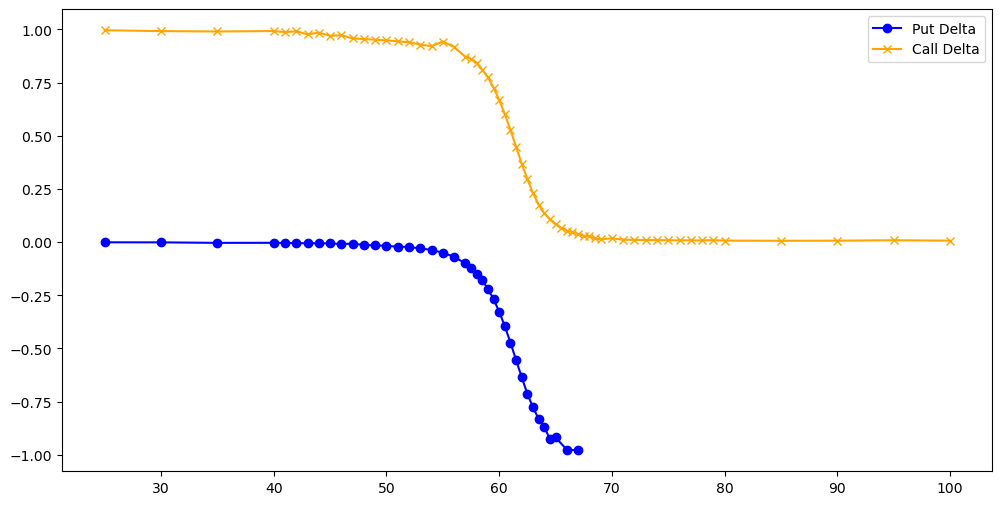

In [9]:
test_put = xlu_filtered_options.loc["2021-01-04"].dropna().sort_values("strike_price")[xlu_filtered_options.loc["2021-01-04"].dropna().sort_values("strike_price")["cp_flag"] == "P"]
test_call = xlu_filtered_options.loc["2021-01-04"].dropna().sort_values("strike_price")[xlu_filtered_options.loc["2021-01-04"].dropna().sort_values("strike_price")["cp_flag"] == "C"]

put_deltas = test_put["delta"]
put_strike_prices = test_put["strike_price"]

call_deltas = test_call["delta"]
call_strike_prices = test_call["strike_price"]

# Plotting
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(put_strike_prices, put_deltas, label="Put Delta", marker='o', color="blue")
plt.plot(call_strike_prices, call_deltas, label="Call Delta", marker='x', color="orange")
plt.legend()

In [10]:
import matplotlib.pyplot as plt

def myround(x, base=5):
    return base * round(x/base)

def delta_adjustment_factor(beta, vrp, upper_threshold):
    return beta * np.exp(vrp - upper_threshold)

def dynamic_width(row, options_df, upper_threshold):
    # Extract VRP and close price rounded to nearest base for ATM strike selection
    vrp = row["vrp"]
    prev_close = myround(row["Close"], 5)
    
    # Get ATM deltas for calls and puts
    atm_put_delta = options_df.query("strike_price == @prev_close and cp_flag == 'P'")["delta"].values[0]
    atm_call_delta = options_df.query("strike_price == @prev_close and cp_flag == 'C'")["delta"].values[0]
    
    # Calculate delta adjustments based on VRP
    delta_adjust = delta_adjustment_factor(0.2, vrp, upper_threshold)
    delta_call_inner = atm_call_delta - delta_adjust
    delta_put_inner = atm_put_delta + delta_adjust
    delta_call_outer = atm_call_delta - 1.2 * delta_adjust
    delta_put_outer = atm_put_delta + 1.2 * delta_adjust
    
    # Find strikes with deltas closest to the calculated values
    options_today = options_df.loc[row.name]
    
    call_inner_strike = options_today.query("cp_flag == 'C'").iloc[
        (options_today.query("cp_flag == 'C'")["delta"] - delta_call_inner).abs().argmin()
    ]["strike_price"]
    
    put_inner_strike = options_today.query("cp_flag == 'P'").iloc[
        (options_today.query("cp_flag == 'P'")["delta"] - delta_put_inner).abs().argmin()
    ]["strike_price"]
    
    call_outer_strike = options_today.query("cp_flag == 'C'").iloc[
        (options_today.query("cp_flag == 'C'")["delta"] - delta_call_outer).abs().argmin()
    ]["strike_price"]
    
    put_outer_strike = options_today.query("cp_flag == 'P'").iloc[
        (options_today.query("cp_flag == 'P'")["delta"] - delta_put_outer).abs().argmin()
    ]["strike_price"]
    
    return {
        "strike1": put_outer_strike,
        "strike2": put_inner_strike,
        "strike3": call_inner_strike,
        "strike4": call_outer_strike
    }


ironcondor_tracker = {}

for index, row in xlu_time_series.iterrows():
    if row["action"] == 1:
        spot_open = row["Open"]

    #     strikes = {
    #     "strike1": myround(spot_open * 0.95, base=5),
    #     "strike2": myround(spot_open * 1, base=5),
    #     "strike3": myround(spot_open * 1, base=5),
    #     "strike4": myround(spot_open * 1.05, base=5)
    # }
        strikes = dynamic_width(row, xlu_filtered_options, upper_threshold)
        
        if row["action"] == 1:
            direction = "long"
            premiums = {
                "premium1": xlu_filtered_options.loc[
                    (xlu_filtered_options.index == index) & 
                    (xlu_filtered_options["strike_price"] == strikes["strike1"]) & 
                    (xlu_filtered_options["cp_flag"] == 'P'), "best_bid"
                ],
                "premium2": xlu_filtered_options.loc[
                    (xlu_filtered_options.index == index) & 
                    (xlu_filtered_options["strike_price"] == strikes["strike2"]) & 
                    (xlu_filtered_options["cp_flag"] == 'P'), "best_offer"
                ],
                "premium3": xlu_filtered_options.loc[
                    (xlu_filtered_options.index == index) & 
                    (xlu_filtered_options["strike_price"] == strikes["strike3"]) & 
                    (xlu_filtered_options["cp_flag"] == 'C'), "best_offer"
                ],
                "premium4": xlu_filtered_options.loc[
                    (xlu_filtered_options.index == index) & 
                    (xlu_filtered_options["strike_price"] == strikes["strike4"]) & 
                    (xlu_filtered_options["cp_flag"] == 'C'), "best_bid"
                ]
            }
        
        expiry = xlu_filtered_options.loc[index]["exdate"].max()

        ironcondor = IronCondor(direction=direction, strikes=strikes, premiums=premiums, expiry=expiry)
        ironcondor_tracker[index] = (ironcondor, expiry)
    
    elif row["action"] == 0:
        ironcondor_tracker[index] = (None, None)

C:\Users\Gavin\AppData\Local\Temp\ipykernel_24400\371489695.py:33: FutureWarning: The behavior of Series.argmax/argmin with skipna=False and NAs, or with all-NAs is deprecated. In a future version this will raise ValueError.
  (options_today.query("cp_flag == 'P'")["delta"] - delta_put_inner).abs().argmin()
C:\Users\Gavin\AppData\Local\Temp\ipykernel_24400\371489695.py:41: FutureWarning: The behavior of Series.argmax/argmin with skipna=False and NAs, or with all-NAs is deprecated. In a future version this will raise ValueError.
  (options_today.query("cp_flag == 'P'")["delta"] - delta_put_outer).abs().argmin()
C:\Users\Gavin\AppData\Local\Temp\ipykernel_24400\371489695.py:33: FutureWarning: The behavior of Series.argmax/argmin with skipna=False and NAs, or with all-NAs is deprecated. In a future version this will raise ValueError.
  (options_today.query("cp_flag == 'P'")["delta"] - delta_put_inner).abs().argmin()
C:\Users\Gavin\AppData\Local\Temp\ipykernel_24400\371489695.py:41: Future

In [11]:
ironcondor_tracker = {}

def find_nearest_strike_delta(date_index, delta_target, option_df, cp_flag):
    """
    Helper function to find the strike with delta closest to delta_target
    """
    options = option_df.loc[date_index].query(f"cp_flag == '{cp_flag}'")
    return options.iloc[(options["delta"] - delta_target).abs().argmin()]["strike_price"]

for index, row in xlu_time_series.iterrows():
    if row["action"] == 1:
        direction = "short"

        spot_open = myround(row["Open"], 5)

        atm_put_strike = xlu_filtered_options.loc[index].query("cp_flag == 'P' and strike_price == @spot_open")["strike_price"].values[0]
        atm_call_strike = xlu_filtered_options.loc[index].query("cp_flag == 'C' and strike_price == @spot_open")["strike_price"].values[0]

        otm_put_strike = find_nearest_strike_delta(index, 0.2, xlu_filtered_options, "P")
        otm_call_strike = find_nearest_strike_delta(index, -0.2, xlu_filtered_options, "C")

        # print(f"date: {index}, Put: {otm_put_strike}, ATM Put: {atm_put_strike}, ATM Call: {atm_call_strike}, OTM Call: {otm_call_strike}")

        strikes = {
            "strike1": otm_put_strike,
            "strike2": atm_put_strike,
            "strike3": atm_call_strike,
            "strike4": otm_call_strike
        }

        # premiums = {
        #     "premium1": xlu_filtered_options.loc[
        #         (xlu_filtered_options.index == index) & 
        #         (xlu_filtered_options["strike_price"] == strikes["strike1"]) & 
        #         (xlu_filtered_options["cp_flag"] == 'P'), "best_bid"
        #     ],
        #     "premium2": xlu_filtered_options.loc[
        #         (xlu_filtered_options.index == index) & 
        #         (xlu_filtered_options["strike_price"] == strikes["strike2"]) & 
        #         (xlu_filtered_options["cp_flag"] == 'P'), "best_offer"
        #     ],
        #     "premium3": xlu_filtered_options.loc[
        #         (xlu_filtered_options.index == index) & 
        #         (xlu_filtered_options["strike_price"] == strikes["strike3"]) & 
        #         (xlu_filtered_options["cp_flag"] == 'C'), "best_offer"
        #     ],
        #     "premium4": xlu_filtered_options.loc[
        #         (xlu_filtered_options.index == index) & 
        #         (xlu_filtered_options["strike_price"] == strikes["strike4"]) & 
        #         (xlu_filtered_options["cp_flag"] == 'C'), "best_bid"
        #     ]
        # }

        premiums = {
            "premium1": xlu_filtered_options.loc[
                (xlu_filtered_options.index == index) & 
                (xlu_filtered_options["strike_price"] == strikes["strike1"]) & 
                (xlu_filtered_options["cp_flag"] == 'P'), "best_offer"
            ],
            "premium2": xlu_filtered_options.loc[
                (xlu_filtered_options.index == index) & 
                (xlu_filtered_options["strike_price"] == strikes["strike2"]) & 
                (xlu_filtered_options["cp_flag"] == 'P'), "best_bid"
            ],
            "premium3": xlu_filtered_options.loc[
                (xlu_filtered_options.index == index) & 
                (xlu_filtered_options["strike_price"] == strikes["strike3"]) & 
                (xlu_filtered_options["cp_flag"] == 'C'), "best_bid"
            ],
            "premium4": xlu_filtered_options.loc[
                (xlu_filtered_options.index == index) & 
                (xlu_filtered_options["strike_price"] == strikes["strike4"]) & 
                (xlu_filtered_options["cp_flag"] == 'C'), "best_offer"
            ]
        }        

        # print(f"date: {index}, Premiums: {premiums}")

        expiry = xlu_filtered_options.loc[index]["exdate"].max()

        ironcondor = IronCondor(direction=direction, strikes=strikes, premiums=premiums, expiry=expiry)
        ironcondor_tracker[index] = (ironcondor, ironcondor.target_profit().iloc[0], expiry)
    elif row["action"] == -1:
        direction = "long"

        spot_open = myround(row["Open"], 5)

        atm_put_strike = xlu_filtered_options.loc[index].query("cp_flag == 'P' and strike_price == @spot_open")["strike_price"].values[0]
        atm_call_strike = xlu_filtered_options.loc[index].query("cp_flag == 'C' and strike_price == @spot_open")["strike_price"].values[0]

        otm_put_strike = find_nearest_strike_delta(index, 0.2, xlu_filtered_options, "P")
        otm_call_strike = find_nearest_strike_delta(index, -0.2, xlu_filtered_options, "C")

        strikes = {
            "strike1": otm_put_strike,
            "strike2": atm_put_strike,
            "strike3": atm_call_strike,
            "strike4": otm_call_strike
        }

        premiums = {
            "premium1": xlu_filtered_options.loc[
                (xlu_filtered_options.index == index) & 
                (xlu_filtered_options["strike_price"] == strikes["strike1"]) & 
                (xlu_filtered_options["cp_flag"] == 'P'), "best_bid"
            ],
            "premium2": xlu_filtered_options.loc[
                (xlu_filtered_options.index == index) & 
                (xlu_filtered_options["strike_price"] == strikes["strike2"]) & 
                (xlu_filtered_options["cp_flag"] == 'P'), "best_offer"
            ],
            "premium3": xlu_filtered_options.loc[
                (xlu_filtered_options.index == index) & 
                (xlu_filtered_options["strike_price"] == strikes["strike3"]) & 
                (xlu_filtered_options["cp_flag"] == 'C'), "best_offer"
            ],
            "premium4": xlu_filtered_options.loc[
                (xlu_filtered_options.index == index) & 
                (xlu_filtered_options["strike_price"] == strikes["strike4"]) & 
                (xlu_filtered_options["cp_flag"] == 'C'), "best_bid"
            ]
        }

        expiry = xlu_filtered_options.loc[index]["exdate"].max()

        ironcondor = IronCondor(direction=direction, strikes=strikes, premiums=premiums, expiry=expiry)
        ironcondor_tracker[index] = (ironcondor, ironcondor.target_profit().iloc[0], expiry)

In [12]:
# pnl_dict = {}

# for index, (ironcondor, target_profit, expiry) in ironcondor_tracker.items():
#     print(f"Processing date: {index}")
#     if ironcondor is not None:
#         half_winner = 0.5 * target_profit
#         options_test_df = xlu_filtered_options.loc[index:expiry + pd.Timedelta(days=1)].query("exdate == @expiry")
#         for date, row in options_test_df.iterrows():
#             ironcondor.insert_spot(xlu_time_series.loc[date]["Close"])
#             if ironcondor.payoff() >= half_winner:
#                 print(f"Half winner achieved on {date}")
#                 ic_strikes = ironcondor.strikes
#                 long_put_buyback = options_test_df.loc[date][
#                     (options_test_df.loc[date]["cp_flag"] == 'P') & 
#                     (options_test_df.loc[date]["strike_price"] == ic_strikes["strike1"])
#                 ]["best_offer"].values[0]
#                 short_put_sellback = options_test_df.loc[date][
#                     (options_test_df.loc[date]["cp_flag"] == 'P') & 
#                     (options_test_df.loc[date]["strike_price"] == ic_strikes["strike2"])
#                 ]["best_bid"].values[0]
#                 short_call_sellback = options_test_df.loc[date][
#                     (options_test_df.loc[date]["cp_flag"] == 'C') & 
#                     (options_test_df.loc[date]["strike_price"] == ic_strikes["strike3"])
#                 ]["best_bid"].values[0]
#                 long_call_buyback = options_test_df.loc[date][
#                     (options_test_df.loc[date]["cp_flag"] == 'C') & 
#                     (options_test_df.loc[date]["strike_price"] == ic_strikes["strike4"])
#                 ]["best_offer"].values[0]
#                 closing_cost = -long_put_buyback + short_put_sellback + short_call_sellback - long_call_buyback
#                 print(f"Half winner: {half_winner}")
#                 print(f"Closing cost: {closing_cost}")
#                 pnl_dict[index] = {"pnl": ironcondor.payoff(), "close_date" : date}
#                 # break
#             else:
#                 pnl_dict[index] = {"pnl": ironcondor.payoff(), "close_date" : expiry}
#     else:
#         pnl_dict[index] = {"pnl": 0, "close_date" : None}

pnl_dict = {}

for index, (ironcondor, target_profit, expiry) in ironcondor_tracker.items():
    print(f"Processing date: {index}, expiry: {expiry}")
    if ironcondor is not None:
        try:
            ironcondor.insert_spot(xlu_time_series.loc[expiry]["Close"])
        except KeyError:
            ironcondor.insert_spot(xlu_time_series.loc[expiry - pd.Timedelta(days=1)]["Close"])
        pnl_dict[index] = ironcondor.payoff()

Processing date: 2016-11-01 00:00:00, expiry: 2016-11-11 00:00:00
Processing date: 2016-11-14 00:00:00, expiry: 2016-11-25 00:00:00
Processing date: 2016-11-15 00:00:00, expiry: 2016-11-25 00:00:00
Processing date: 2016-11-29 00:00:00, expiry: 2016-12-09 00:00:00
Processing date: 2016-12-13 00:00:00, expiry: 2016-12-23 00:00:00
Processing date: 2016-12-28 00:00:00, expiry: 2017-01-06 00:00:00
Processing date: 2017-01-20 00:00:00, expiry: 2017-02-03 00:00:00
Processing date: 2017-01-31 00:00:00, expiry: 2017-02-10 00:00:00
Processing date: 2017-02-22 00:00:00, expiry: 2017-03-03 00:00:00
Processing date: 2017-03-09 00:00:00, expiry: 2017-03-17 00:00:00
Processing date: 2017-03-16 00:00:00, expiry: 2017-03-24 00:00:00
Processing date: 2017-04-06 00:00:00, expiry: 2017-04-13 00:00:00
Processing date: 2017-05-18 00:00:00, expiry: 2017-05-26 00:00:00
Processing date: 2017-06-02 00:00:00, expiry: 2017-06-16 00:00:00
Processing date: 2017-06-30 00:00:00, expiry: 2017-07-14 00:00:00
Processing

<Axes: xlabel='Date'>

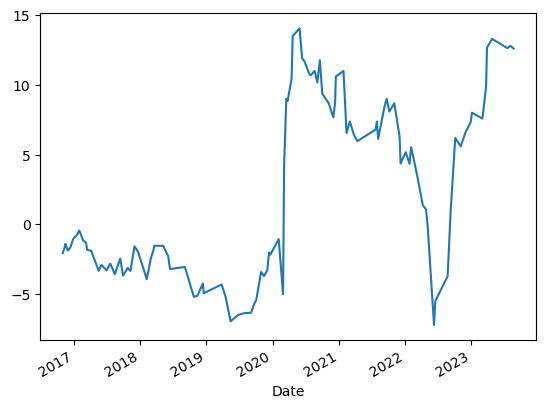

In [13]:
pd.DataFrame(pnl_dict.items(), columns=["Date", "PnL"]).set_index("Date").PnL.cumsum().plot()

In [14]:
pd.DataFrame(pnl_dict).T.pnl.cumsum().plot()

ValueError: If using all scalar values, you must pass an index

In [ ]:
pnl_dict = {}
for date, (ironcondor, expiry) in ironcondor_tracker.items():
    try:
        ironcondor.insert_spot(xlu_time_series.at[expiry, "Close"])
        pnl_dict[date] = ironcondor.payoff()
    except KeyError:
        continue
    except AttributeError:
        pnl_dict[date] = 0

ValueError: too many values to unpack (expected 2)

In [ ]:
pd.Series(pnl_dict).cumsum().plot()

TypeError: unsupported operand type(s) for +: 'float' and 'Timestamp'

# XLF data backtesting

## Pulling data

In [ ]:
xlf_pred = pd.read_csv("data/XLF_pred.csv", parse_dates=True, index_col=0).rename(columns={"0": "Rolling Pred"})
xlf_iv = pd.read_csv("data/XLF_IV.csv", parse_dates=True, index_col=0)
xlf_vrp = (xlf_iv["Average IV"] - xlf_pred["Rolling Pred"]).dropna()

In [ ]:
xlf_vrp

2017-09-13    0.285905
2017-09-14    0.862677
2017-09-15    0.034844
2017-09-18    0.052026
2017-09-19    0.225910
                ...   
2023-08-25   -0.083507
2023-08-28    0.043676
2023-08-29    0.116278
2023-08-30    0.241644
2023-08-31    0.640602
Length: 1502, dtype: float64

<Axes: >

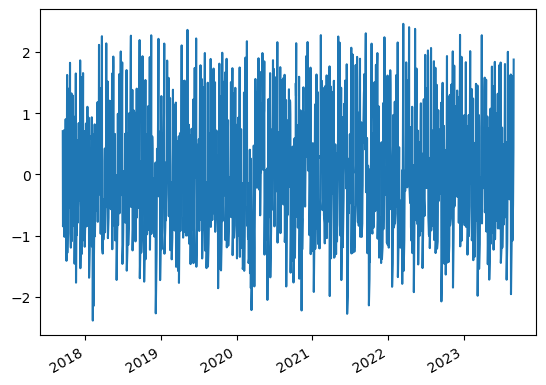

In [ ]:
from data_wrangling import rolling_z_score
xlf_vrp_standardised = rolling_z_score(xlf_vrp, window=10)
xlf_vrp_standardised.plot()

### Merge VRP data with options data

In [ ]:
upper_threshold = 1.75
lower_threshold = -1.75

day_map = {0: "Monday", 1: "Tuesday", 2: "Wednesday", 3: "Thursday", 4: "Friday", 5: "Saturday", 6: "Sunday"}

xlf_options = pd.read_hdf("data/etf_options_data.hf5", key="XLF")
xlf_options = xlf_options.set_index("date")
xlf_options["strike_price"] = xlf_options["strike_price"] / 1000
xlf_filtered_options = xlf_options.groupby("date").apply(lambda x: x.query("exdate == exdate.min()")).reset_index(level=0, drop=True)
xlf_filtered_options["day"] = xlf_filtered_options.index.weekday.map(day_map)
xlf_filtered_options["ex_day"] = xlf_filtered_options["exdate"].dt.weekday.map(day_map)
xlf_filtered_options

xlf_filtered_options["vrp"] = xlf_vrp_standardised
xlf_time_series = pd.read_hdf("data/etf_series.hf5", key="XLF")
xlf_time_series["day"] = xlf_time_series.index.weekday
xlf_time_series["vrp"] = xlf_vrp_standardised
xlf_time_series["signal"] = np.where(xlf_time_series["vrp"] > upper_threshold, 1, np.where(xlf_time_series["vrp"] < lower_threshold, -1, 0))
xlf_time_series["action"] = np.where((xlf_time_series["signal"] == 1)  & (xlf_time_series.index.weekday != 4), 1, 
                                     np.where((xlf_time_series["signal"] == -1) & (xlf_time_series.index.weekday != 4), -1, 
                                              0))
xlf_time_series.dropna(inplace=True)
xlf_time_series

def ensure_weekly_action(df):
    last_action = 0
    last_week = -1

    for i in range(len(df)):
        current_week = df.index[i].isocalendar()[1]  # Get the week number
        current_day = df["day"].iloc[i]

        if current_week != last_week:  # Reset at the start of a new week
            last_action = 0
            last_week = current_week

        if last_action != 0 and df["action"].iloc[i] != 0:
            # If an action has already occurred this week, set to 0
            df.at[df.index[i], "action"] = 0
        elif df["action"].iloc[i] != 0:
            # If this is the first action of the week, update last_action
            last_action = df["action"].iloc[i]

    return df

xlf_time_series = ensure_weekly_action(xlf_time_series)
xlf_time_series["action"] = xlf_time_series["action"].shift()
xlf_time_series

,Open,High,Low,Close,Adj Close,Volume,day,vrp,signal,action
Date,,,,,,,,,,
2017-09-14,24.860001,24.920000,24.750000,24.799999,21.523062,47163200,3,0.707107,0,NaN
2017-09-15,24.660000,24.790001,24.629999,24.770000,21.586683,59250200,4,-0.847265,0,0.0
2017-09-18,24.860001,25.070000,24.840000,25.059999,21.839409,44010400,0,-0.664415,0,0.0
2017-09-19,25.059999,25.309999,25.020000,25.250000,22.004993,58443300,1,-0.197025,0,0.0
2017-09-20,25.270000,25.490000,25.150000,25.400000,22.135714,70595500,2,0.402541,0,0.0
...,...,...,...,...,...,...,...,...,...,...
2023-08-25,33.970001,34.119999,33.709999,33.990002,33.292690,40347200,4,-1.080421,0,0.0
2023-08-28,34.099998,34.299999,34.070000,34.180000,33.478794,34905300,0,-0.484978,0,0.0
2023-08-29,34.150002,34.500000,34.099998,34.490002,33.782436,43394300,1,-0.118561,0,0.0


In [ ]:
def myround(x, base=5):
    return base * round(x/base)


ironcondor_tracker = {}

for index, row in xlf_time_series.iterrows():
    if row["action"] == 1:
        spot_open = row["Open"]

        strikes = {
        "strike1": myround(spot_open * 0.95, base=5),
        "strike2": myround(spot_open * 1, base=5),
        "strike3": myround(spot_open * 1, base=5),
        "strike4": myround(spot_open * 1.05, base=5)
    }
        
        if row["action"] == 1:
            direction = "long"
            premiums = {
                "premium1": xlf_filtered_options.loc[
                    (xlf_filtered_options.index == index) & 
                    (xlf_filtered_options["strike_price"] == strikes["strike1"]) & 
                    (xlf_filtered_options["cp_flag"] == 'P'), "best_bid"
                ],
                "premium2": xlf_filtered_options.loc[
                    (xlf_filtered_options.index == index) & 
                    (xlf_filtered_options["strike_price"] == strikes["strike2"]) & 
                    (xlf_filtered_options["cp_flag"] == 'P'), "best_offer"
                ],
                "premium3": xlf_filtered_options.loc[
                    (xlf_filtered_options.index == index) & 
                    (xlf_filtered_options["strike_price"] == strikes["strike3"]) & 
                    (xlf_filtered_options["cp_flag"] == 'C'), "best_offer"
                ],
                "premium4": xlf_filtered_options.loc[
                    (xlf_filtered_options.index == index) & 
                    (xlf_filtered_options["strike_price"] == strikes["strike4"]) & 
                    (xlf_filtered_options["cp_flag"] == 'C'), "best_bid"
                ]
            }
        # if row["action"] == -1:
        #     direction = "short"
        #     premiums = {
        #         "premium1": xlf_filtered_options.loc[
        #             (xlf_filtered_options.index == index) & 
        #             (xlf_filtered_options["strike_price"] == strikes["strike1"]) & 
        #             (xlf_filtered_options["cp_flag"] == 'P'), "best_offer"
        #         ],
        #         "premium2": xlf_filtered_options.loc[
        #             (xlf_filtered_options.index == index) & 
        #             (xlf_filtered_options["strike_price"] == strikes["strike2"]) & 
        #             (xlf_filtered_options["cp_flag"] == 'P'), "best_bid"
        #         ],
        #         "premium3": xlf_filtered_options.loc[
        #             (xlf_filtered_options.index == index) & 
        #             (xlf_filtered_options["strike_price"] == strikes["strike3"]) & 
        #             (xlf_filtered_options["cp_flag"] == 'C'), "best_bid"
        #         ],
        #         "premium4": xlf_filtered_options.loc[
        #             (xlf_filtered_options.index == index) & 
        #             (xlf_filtered_options["strike_price"] == strikes["strike4"]) & 
        #             (xlf_filtered_options["cp_flag"] == 'C'), "best_offer"
        #         ]
        #     }
        
        expiry = xlf_filtered_options.loc[index]["exdate"].min()

        ironcondor = IronCondor(direction=direction, strikes=strikes, premiums=premiums, expiry=expiry)
        ironcondor_tracker[index] = (ironcondor, expiry)
    
    elif row["action"] == 0:
        ironcondor_tracker[index] = (None, None)

In [ ]:
ironcondor_tracker

{Timestamp('2017-09-15 00:00:00'): (None, None),
 Timestamp('2017-09-18 00:00:00'): (None, None),
 Timestamp('2017-09-19 00:00:00'): (None, None),
 Timestamp('2017-09-20 00:00:00'): (None, None),
 Timestamp('2017-09-21 00:00:00'): (None, None),
 Timestamp('2017-09-22 00:00:00'): (None, None),
 Timestamp('2017-09-25 00:00:00'): (None, None),
 Timestamp('2017-09-26 00:00:00'): (None, None),
 Timestamp('2017-09-27 00:00:00'): (None, None),
 Timestamp('2017-09-28 00:00:00'): (None, None),
 Timestamp('2017-09-29 00:00:00'): (None, None),
 Timestamp('2017-10-02 00:00:00'): (None, None),
 Timestamp('2017-10-03 00:00:00'): (None, None),
 Timestamp('2017-10-04 00:00:00'): (None, None),
 Timestamp('2017-10-05 00:00:00'): (None, None),
 Timestamp('2017-10-06 00:00:00'): (None, None),
 Timestamp('2017-10-09 00:00:00'): (None, None),
 Timestamp('2017-10-10 00:00:00'): (None, None),
 Timestamp('2017-10-11 00:00:00'): (None, None),
 Timestamp('2017-10-12 00:00:00'): (None, None),
 Timestamp('2017-10-

In [ ]:
pnl_dict = {}
for date, (ironcondor, expiry) in ironcondor_tracker.items():
    try:
        ironcondor.insert_spot(xlf_time_series.at[expiry, "Close"])
        pnl_dict[date] = ironcondor.payoff()
    except KeyError:
        continue
    except AttributeError:
        pnl_dict[date] = 0

C:\Users\Gavin\AppData\Local\Temp\ipykernel_17392\1377766752.py:93: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(total_payoff)


<Axes: >

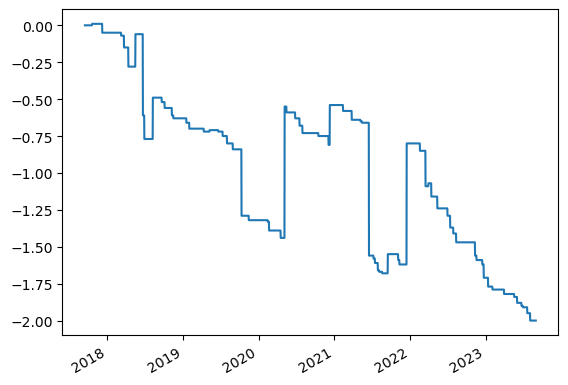

In [ ]:
pd.Series(pnl_dict).cumsum().plot()